# Classification Track (Part A) - Hotel Booking Demand

**Problem statement.** Predict `is_canceled` - whether a booking will
eventually be cancelled - from the attributes known at the time the booking
is made. A hotel that can flag a booking as high-cancellation-risk before
arrival can overbook more safely and target retention offers at the guests
most likely to cancel.

**Dataset.** `data/hotel_bookings.csv`, 119,390 bookings x 32 columns, from
Antonio, Almeida & Nunes (2019), *Hotel booking demand datasets*,
Data in Brief 22:41-49. Same file as the regression track; different target,
so the cleaning and leakage rules below are worked out independently for
`is_canceled` rather than reused from the regression notebook.

**Scope of this notebook.** Review 1 covers Classification Part A: the first
five algorithms (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM).
Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the
consolidated ten-algorithm comparison are added for Review 2.

**Notebook map** (rubric references in brackets):

| Section | Contents | Rubric |
|---|---|---|
| 1 | Load & audit | A1 |
| 2 | Exploratory data analysis | A2, A3 |
| 3 | Cleaning | B1 |
| 4 | Feature engineering | B3 |
| 5 | Encoding, scaling & splitting | B2 |
| 6 | Five classification algorithms | D1 |
| 7 | Comparative evaluation | D2 |
| 8 | Cross-validation | (7.2) |
| 9 | Conclusion | - |


In [24]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Logistic Regression can warn about the L-BFGS iteration cap on the
# one-hot-expanded feature space; we raise max_iter where it matters and do
# not want the notebook output buried under convergence warnings.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA = "../data/hotel_bookings.csv"


## 1. Load & audit  *(A1)*

In [25]:
df_raw = pd.read_csv(DATA)
print(f"rows: {df_raw.shape[0]:,}    columns: {df_raw.shape[1]}")
df_raw.head()


rows: 119,390    columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [26]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(),
})
audit


,dtype,missing,missing_%,unique
hotel,str,0,0.00,2
is_canceled,int64,0,0.00,2
lead_time,int64,0,0.00,479
arrival_date_year,int64,0,0.00,3
arrival_date_month,str,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
arrival_date_day_of_month,int64,0,0.00,31
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35
adults,int64,0,0.00,14


In [27]:
print("Target `is_canceled` (0 = kept, 1 = cancelled)")
counts = df_raw["is_canceled"].value_counts()
rate = df_raw["is_canceled"].mean() * 100
print(counts)
print(f"\ncancellation rate: {rate:.1f}%")


Target `is_canceled` (0 = kept, 1 = cancelled)
is_canceled
0    75166
1    44224
Name: count, dtype: int64

cancellation rate: 37.0%


**Observation.** No column is fully empty, but four have gaps worth a
deliberate rule rather than a blanket fill: `company` (94.3%), `agent`
(13.7%), `country` (0.4%) and `children` (4 rows) - handled individually in
Section 3.2. The target is imbalanced at roughly 37% cancelled against 63%
kept, not extreme, but weighted F1 rather than plain accuracy is used
throughout so the majority class does not dominate the score.

## 2. Exploratory data analysis  *(A2, A3)*

### 2.1 Target distribution

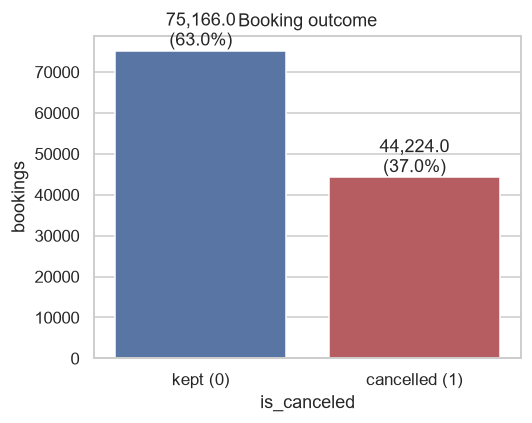

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_raw, x="is_canceled", hue="is_canceled",
              palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set(title="Booking outcome", xlabel="is_canceled", ylabel="bookings")
ax.set_xticks([0, 1])
ax.set_xticklabels(["kept (0)", "cancelled (1)"])
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}\n({p.get_height()/len(df_raw)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Observation:** 63% of bookings are kept and 37% cancelled. That is
close enough to balanced that no resampling (SMOTE, class weighting) is
needed to get a usable model, but it is skewed enough that plain accuracy is
misleading - a model that always predicts "kept" already scores 63%. Weighted
F1 and the confusion matrix in Section 7 are what actually judge these
models.

### 2.2 Distributions of the numeric features

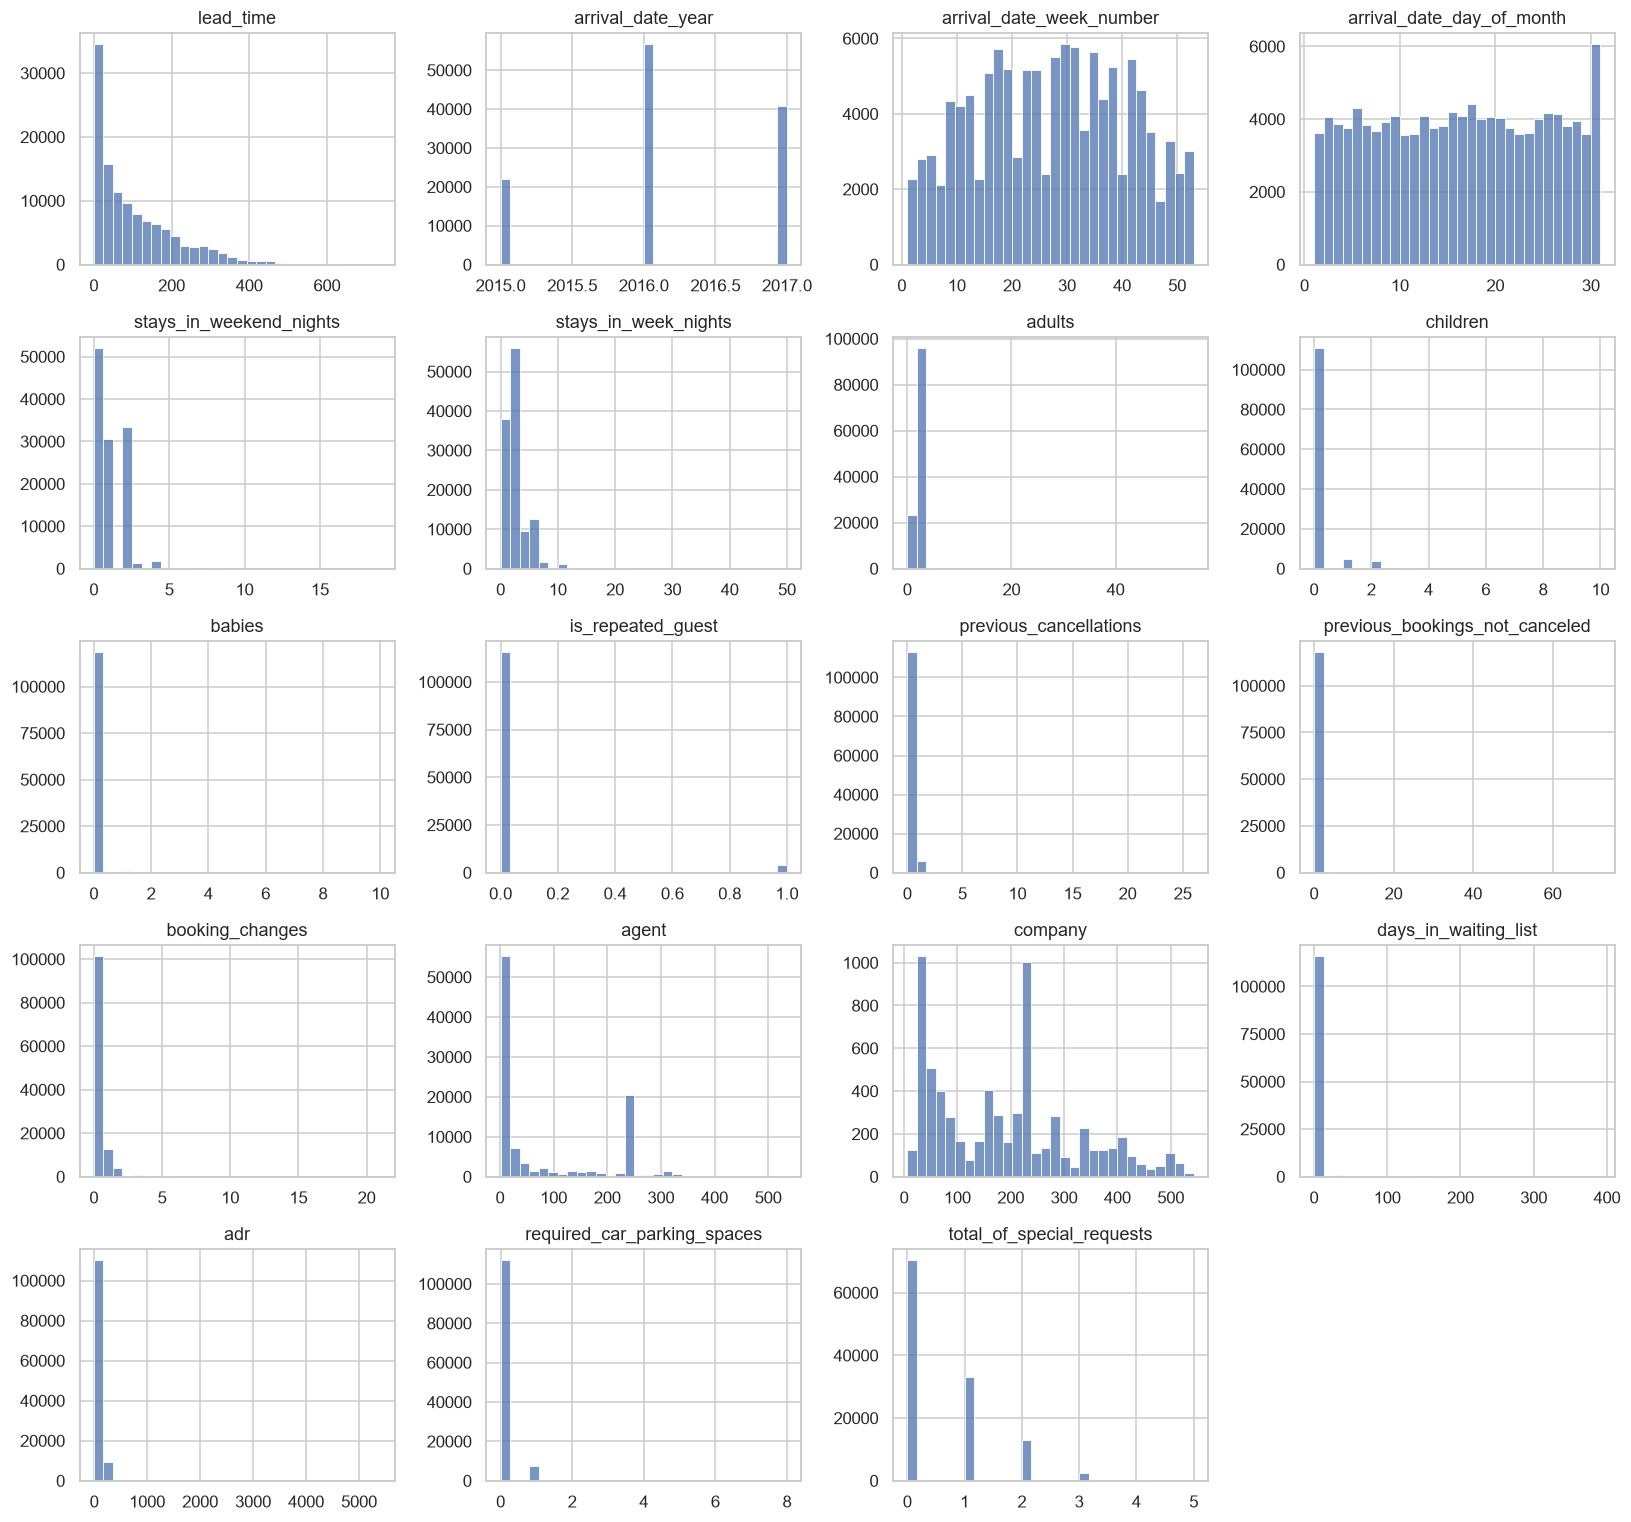

In [29]:
numeric_raw = df_raw.select_dtypes("number").columns.drop(["is_canceled"])
fig, axes = plt.subplots(5, 4, figsize=(15, 14))
for ax, col in zip(axes.ravel(), numeric_raw):
    sns.histplot(df_raw[col], bins=30, ax=ax, color="#4C72B0")
    ax.set(title=col, xlabel="", ylabel="")
for ax in axes.ravel()[len(numeric_raw):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


**Observation:** Most numeric columns are heavily right-skewed or zero
inflated - `previous_cancellations`, `booking_changes`,
`days_in_waiting_list`, `babies`, `required_car_parking_spaces` - the same
pattern seen in the regression notebook, since it is the same raw table.
`lead_time` in particular has a long tail out past 400 days; Section 2.4
checks whether that tail carries cancellation signal.

### 2.3 Correlation structure

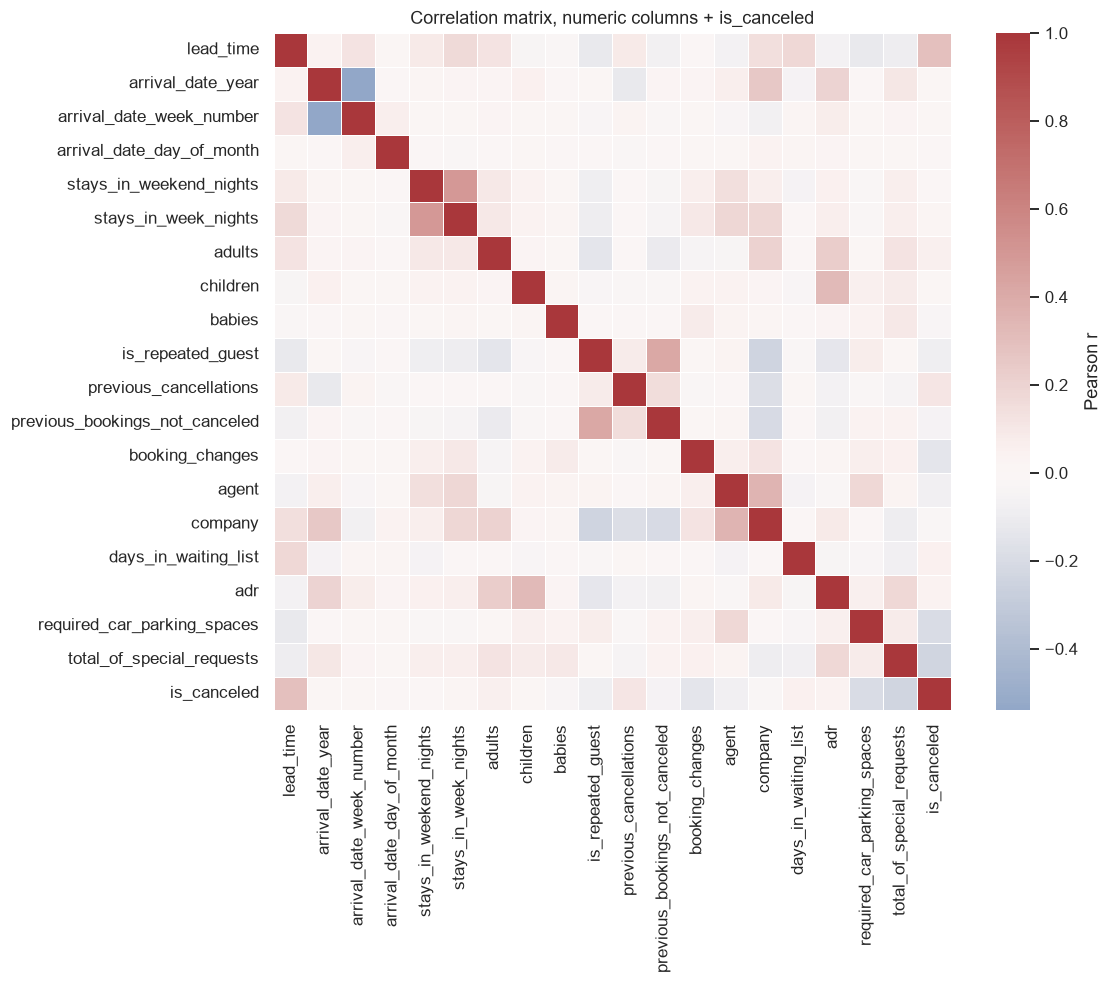

lead_time                         0.293
total_of_special_requests        -0.235
required_car_parking_spaces      -0.195
booking_changes                  -0.144
previous_cancellations            0.110
is_repeated_guest                -0.085
agent                            -0.083
adults                            0.060
previous_bookings_not_canceled   -0.057
days_in_waiting_list              0.054
adr                               0.048
babies                           -0.032
stays_in_week_nights              0.025
company                          -0.021
arrival_date_year                 0.017
arrival_date_week_number          0.008
arrival_date_day_of_month        -0.006
children                          0.005
stays_in_weekend_nights          -0.002
Name: is_canceled, dtype: float64


In [30]:
corr_cols = list(numeric_raw) + ["is_canceled"]
corr = df_raw[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=True,
            linewidths=.4, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix, numeric columns + is_canceled")
plt.tight_layout()
plt.show()

print(corr["is_canceled"].drop("is_canceled").sort_values(key=abs, ascending=False).round(3))


**Observation.** `lead_time` is the strongest single numeric
correlate of cancellation (r ~ 0.29): bookings made far in advance are more
likely to fall through. `total_of_special_requests` and
`required_car_parking_spaces` both correlate negatively - guests who commit
to specifics tend to follow through. `previous_cancellations` correlates
positively but weakly on its own, which is why Section 4 combines it with
`previous_bookings_not_canceled` into a rate rather than using the raw
count.

### 2.4 Feature-target relationships

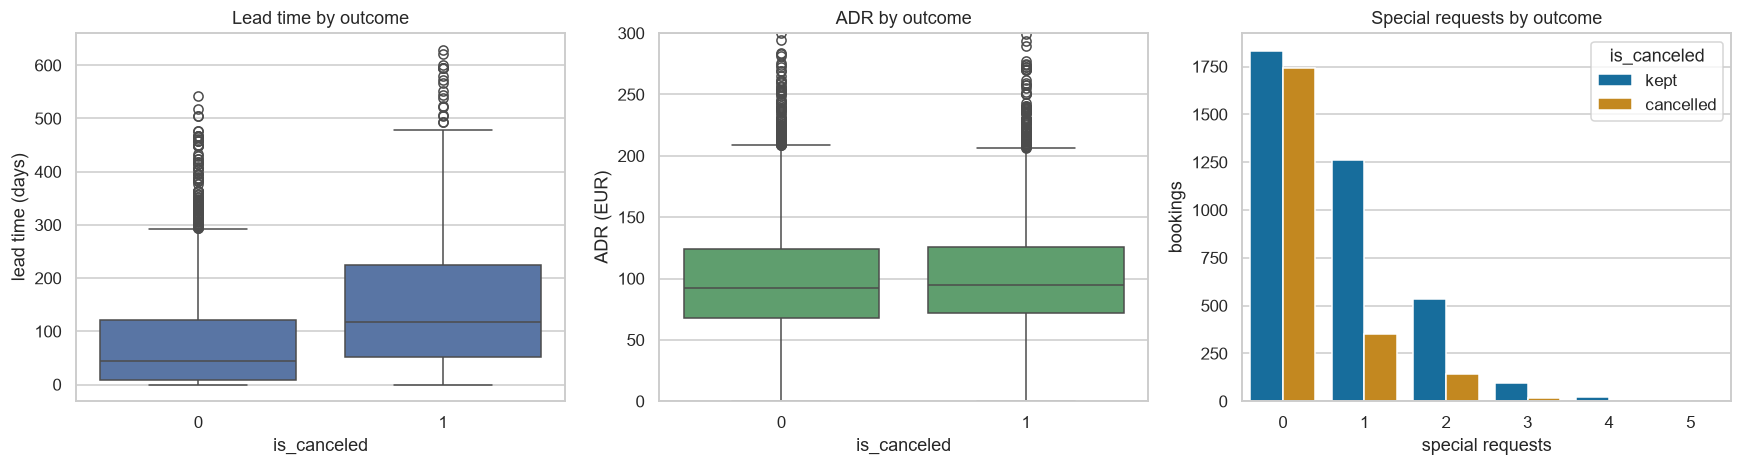

In [31]:
sample = df_raw.sample(6000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

sns.boxplot(data=sample, x="is_canceled", y="lead_time", ax=axes[0], color="#4C72B0")
axes[0].set(title="Lead time by outcome", xlabel="is_canceled", ylabel="lead time (days)")

sns.boxplot(data=sample, x="is_canceled", y="adr", ax=axes[1], color="#55A868")
axes[1].set(title="ADR by outcome", xlabel="is_canceled", ylabel="ADR (EUR)", ylim=(0, 300))

sns.countplot(data=sample, x="total_of_special_requests", hue="is_canceled",
              ax=axes[2])
axes[2].set(title="Special requests by outcome", xlabel="special requests", ylabel="bookings")
axes[2].legend(title="is_canceled", labels=["kept", "cancelled"])

plt.tight_layout()
plt.show()


**Observation.** Cancelled bookings have a visibly higher median lead
time and a fatter upper whisker - the longer a booking sits on the books,
the more chances something changes. ADR barely separates the two groups,
consistent with Section 2.3's weak correlation. Special requests fall off
sharply for cancelled bookings: guests with zero special requests cancel
noticeably more often than guests with two or more, which reads as
engagement with the specific stay rather than a generic reservation.

### 2.5 Categorical drivers

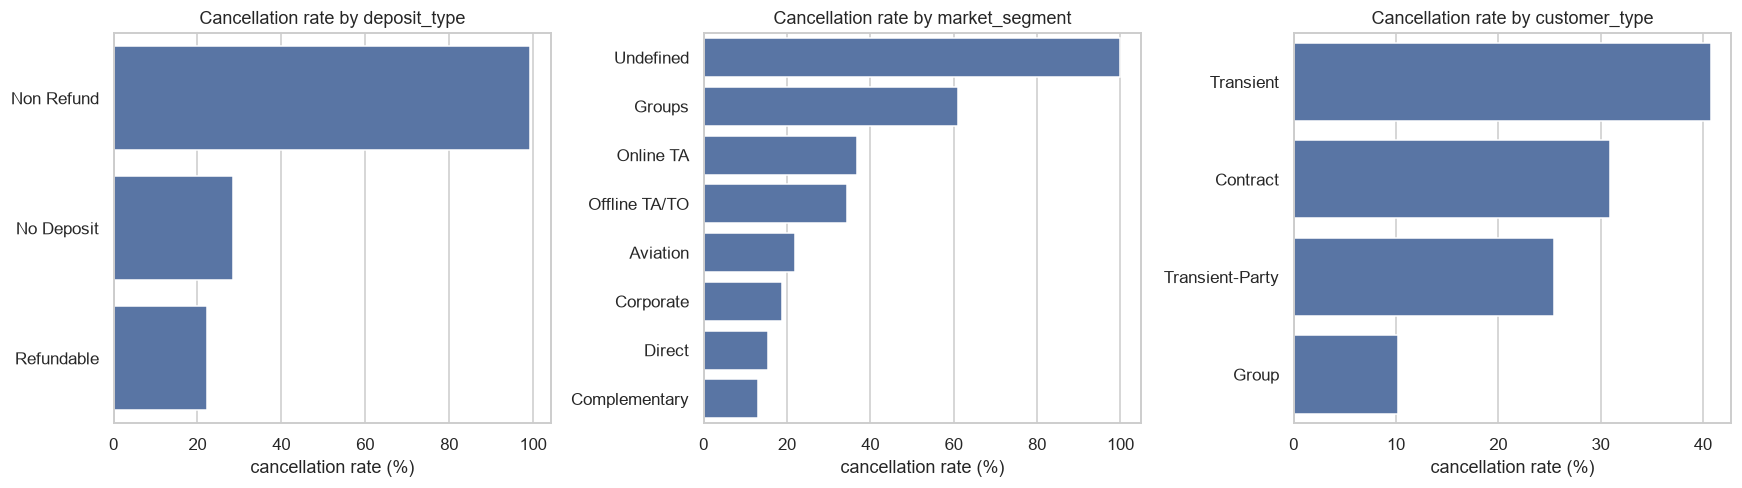

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for ax, col in zip(axes, ["deposit_type", "market_segment", "customer_type"]):
    rate = df_raw.groupby(col)["is_canceled"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="#4C72B0")
    ax.set(title=f"Cancellation rate by {col}", xlabel="cancellation rate (%)", ylabel="")

plt.tight_layout()
plt.show()


**Observation.** `deposit_type` is the standout, and counter-intuitively
so: `Non Refund` bookings cancel at a far higher rate than `No Deposit`
bookings, the opposite of what a deposit is supposed to achieve. This is a
known quirk of this dataset traced to a block of agency bookings, and it is
exactly the kind of signal a model can pick up even though it would not
generalise to hotels with normal deposit incentives - worth surfacing in the
viva. `market_segment` shows `Groups` cancelling far more than `Direct` or
`Corporate`, and `customer_type` shows `Transient` guests cancelling more
than `Group` or `Contract` guests.

## 3. Cleaning  *(B1)*

### 3.1 Columns that cannot be used

The prediction moment is fixed by the problem statement: **the instant the
booking is made**. Any column only settled after that point is a leak,
however predictive.

In [33]:
LEAKY = {
    "reservation_status":      "check-out / cancelled / no-show - this *is* the outcome",
    "reservation_status_date": "the date that status was set - same information",
    "assigned_room_type":      "the room actually given, decided at check-in",
}

print("reservation_status vs is_canceled - why it has to go:")
print(pd.crosstab(df_raw["reservation_status"], df_raw["is_canceled"]))

df = df_raw.drop(columns=list(LEAKY))
for col, why in LEAKY.items():
    print(f"\ndropped  {col:24s}  {why}")
print(f"\ncolumns: {df_raw.shape[1]} -> {df.shape[1]}")


reservation_status vs is_canceled - why it has to go:
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207

dropped  reservation_status        check-out / cancelled / no-show - this *is* the outcome

dropped  reservation_status_date   the date that status was set - same information

dropped  assigned_room_type        the room actually given, decided at check-in

columns: 32 -> 29


**Observation.** `reservation_status` maps onto `is_canceled` almost
one-to-one - every `Canceled` row is `is_canceled = 1` and every `Check-Out`
row is `is_canceled = 0` (`No-Show` also counts as cancelled here). Training
on it would give near-perfect accuracy for a reason that is useless in
practice: it is the answer, recorded after the fact, not a predictor.
`assigned_room_type` is tempting because it correlates with cancellation
(mismatched assignments are rarer for guests who never show up to notice),
but it is only known at check-in, so it is dropped for the same reason as in
the regression notebook.

### 3.2 Missing values - four columns, four treatments

In [34]:
# company: 94.3% missing. The id itself is unusable, but whether a corporate
# account was attached is a genuine signal, so keep the flag and drop the id.
df["has_company"] = df["company"].notna().astype(int)
df = df.drop(columns=["company"])

# agent: a blank means "booked without a travel agent" - informative absence.
# Keep it as a category with an explicit level rather than imputing an id.
df["has_agent"] = df["agent"].notna().astype(int)
df["agent"] = df["agent"].fillna(0).astype(int).astype(str)

# children: 4 rows, and a missing child count means no children were declared.
df["children"] = df["children"].fillna(0)

# country: 0.4% genuinely unknown - gets its own level, not a mode fill, so
# the model can learn whether an unknown origin behaves differently.
df["country"] = df["country"].fillna("Unknown")

# meal: "Undefined" and "SC" both mean no meal package (Antonio et al. 2019).
df["meal"] = df["meal"].replace({"Undefined": "SC"})

print(f"remaining missing values: {df.isna().sum().sum()}")
print(f"\nhas_company = 1 : {df['has_company'].mean() * 100:5.2f}%")
print(f"has_agent   = 1 : {df['has_agent'].mean() * 100:5.2f}%")
print(f"meal levels     : {sorted(df['meal'].unique())}")


remaining missing values: 0

has_company = 1 :  5.69%
has_agent   = 1 : 86.31%
meal levels     : ['BB', 'FB', 'HB', 'SC']


**Observation.** Same four columns as the regression track need
attention, and the same reasoning applies since it is a property of the raw
data rather than the target: nothing gets a mean or mode fill. Three gaps
are structural absences worth keeping as flags, and only `children` gets a
constant fill, justified by it being 4 rows out of 119,390.

### 3.3 Invalid rows

In [35]:
rows = [("raw", len(df))]

df = df[(df["adults"] + df["children"] + df["babies"]) > 0]
rows.append(("after zero-guest filter", len(df)))

df = df[df["adr"] >= 0]
rows.append(("after negative-ADR filter", len(df)))

df = df.drop_duplicates().reset_index(drop=True)
rows.append(("after de-duplication", len(df)))

log = pd.DataFrame(rows, columns=["stage", "rows"])
log["removed"] = -log["rows"].diff().fillna(0).astype(int)
log["% of raw"] = (log["rows"] / rows[0][1] * 100).round(1)
log


,stage,rows,removed,% of raw
0,raw,119390,0,100.0
1,after zero-guest filter,119210,180,99.8
2,after negative-ADR filter,119209,1,99.8
3,after de-duplication,85975,33234,72.0


In [36]:
print(f"clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\ncancellation rate after cleaning: {df['is_canceled'].mean() * 100:.1f}%")


clean dataset: 85,975 rows x 30 columns

cancellation rate after cleaning: 27.6%


**Observation.** Zero-guest rows (180) are a data-entry error rather
than a real booking, the single negative-ADR row is the same. Duplicates take
the largest bite at roughly 28% of rows. Unlike the regression track, this
one is not neutral: the cancellation rate drops from 37.0% before cleaning to
27.6% after, because duplicated rows cancel at 57% against 26% for
non-duplicated rows - large identical-looking blocks (group and online-TA
bookings, per Section 2.5) are exactly the ones over-represented by exact
duplication. Dropping them is still correct, since a repeated row would
otherwise be counted - and could land in both train and test - multiple
times, but it does shift the class balance the models are trained on.

## 4. Feature engineering  *(B3)*

In [37]:
MONTHS = ["January", "February", "March", "April", "May", "June", "July",
          "August", "September", "October", "November", "December"]

# Party composition - Section 2.5 showed engagement signals (special
# requests) matter more than raw numbers, but who is in the booking still
# shapes how committed it is.
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["is_family"]    = ((df["children"] + df["babies"]) > 0).astype(int)

# Stay length - a one-night booking and a two-week booking carry different
# cancellation risk even at the same lead time.
df["total_nights"]  = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["weekend_ratio"] = df["stays_in_weekend_nights"] / df["total_nights"].replace(0, np.nan)
df["weekend_ratio"] = df["weekend_ratio"].fillna(0)

# Seasonality - week 52 and week 1 are adjacent in the calendar but 51 apart
# on a number line. Sine/cosine restores that adjacency for non-tree models.
df["month_num"] = df["arrival_date_month"].map({m: i + 1 for i, m in enumerate(MONTHS)})
df["week_sin"]  = np.sin(2 * np.pi * df["arrival_date_week_number"] / 52)
df["week_cos"]  = np.cos(2 * np.pi * df["arrival_date_week_number"] / 52)

# Guest history - the single strongest engineered signal for this target.
# previous_cancellations alone (Section 2.3) barely correlates with the
# outcome because it does not distinguish a guest with 1 cancellation out of
# 1 stay from one with 1 cancellation out of 20. The rate does.
df["prev_total"]       = df["previous_cancellations"] + df["previous_bookings_not_canceled"]
df["prev_cancel_rate"] = df["previous_cancellations"] / (df["prev_total"] + 1)

df = df.drop(columns=["arrival_date_month"])

NEW = ["total_guests", "is_family", "total_nights", "weekend_ratio",
       "month_num", "week_sin", "week_cos", "prev_total", "prev_cancel_rate",
       "has_agent", "has_company"]
print(f"{len(NEW)} engineered features\n")
df[NEW].describe().T.round(3)


11 engineered features



,count,mean,std,min,25%,50%,75%,max
total_guests,85975.0,2.034,0.792,1.0,2.000,2.000,2.000,55.000
is_family,85975.0,0.106,0.307,0.0,0.000,0.000,0.000,1.000
total_nights,85975.0,3.640,2.749,0.0,2.000,3.000,5.000,69.000
weekend_ratio,85975.0,0.264,0.280,0.0,0.000,0.250,0.400,1.000
month_num,85975.0,6.466,3.096,1.0,4.000,7.000,9.000,12.000
week_sin,85975.0,-0.008,0.712,-1.0,-0.749,-0.000,0.749,1.000
week_cos,85975.0,-0.143,0.687,-1.0,-0.823,-0.239,0.465,1.000
prev_total,85975.0,0.217,1.922,0.0,0.000,0.000,0.000,78.000
prev_cancel_rate,85975.0,0.007,0.059,0.0,0.000,0.000,0.000,0.963
has_agent,85975.0,0.862,0.345,0.0,1.000,1.000,1.000,1.000


In [38]:
engineered_corr = (df[NEW + ["is_canceled"]].corr()["is_canceled"]
                   .drop("is_canceled").sort_values(key=abs, ascending=False))
print("Correlation with is_canceled:")
print(engineered_corr.round(3))


Correlation with is_canceled:
prev_cancel_rate    0.160
has_agent           0.134
total_guests        0.098
has_company        -0.094
total_nights        0.084
week_cos           -0.072
is_family           0.051
prev_total         -0.038
month_num           0.006
week_sin           -0.003
weekend_ratio       0.002
Name: is_canceled, dtype: float64


**Observation.** `prev_cancel_rate` is the strongest engineered
feature (r = 0.160) - it captures something no raw column does directly: a
guest's own track record. `has_agent` is a close second (r = 0.134),
consistent with the deposit/agency pattern already visible in Section 2.5.
`weekend_ratio` and `week_sin` are essentially flat (r < 0.01); party
composition and calendar position matter far less here than they did for
`adr` in the regression track. These engineered columns are not expected to
dominate individually - tree-based models in Part B will combine them with
the raw columns in ways a single correlation coefficient cannot show.

## 5. Encoding, scaling & splitting  *(B2)*

### 5.1 High-cardinality categoricals

Same issue as the regression track: `country` has 178 levels and `agent`
334. One-hot encoding them as-is would add hundreds of sparse columns, most
of them near-constant zero for any given model. Grouping the long tail into
`Other` keeps the useful levels and drops the noise.

In [39]:
TOP_N = {"country": 20, "agent": 15}

for col, n in TOP_N.items():
    top = df[col].value_counts().nlargest(n).index
    covered = df[col].isin(top).mean() * 100
    print(f"{col:8s}: {df[col].nunique():4d} levels -> top {n} cover {covered:.1f}% of rows")
    df[col] = np.where(df[col].isin(top), df[col], "Other")

print()
print(df[["country", "agent"]].nunique().to_string())


country :  178 levels -> top 20 cover 92.5% of rows
agent   :  334 levels -> top 15 cover 84.4% of rows

country    21
agent      16


### 5.2 Preprocessing pipeline and split

Every transform lives inside a `ColumnTransformer` fit only on the training
split, then applied to both splits - fitting a scaler or encoder on the full
dataset before splitting would leak test-set statistics into training, an
explicit data-leakage error under the course guidelines. The split is
stratified on `is_canceled` itself, which is the natural choice for a
classification target (no banding trick needed, unlike the continuous `adr`
target in the regression notebook).

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

CATEGORICAL = X.select_dtypes(include=["object", "str"]).columns.tolist()
NUMERIC = [c for c in X.columns if c not in CATEGORICAL]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

n_features = preprocessor.fit_transform(X_train).shape[1]
print(f"categorical columns : {len(CATEGORICAL):2d}  {CATEGORICAL}")
print(f"numeric columns     : {len(NUMERIC):2d}")
print(f"after encoding      : {n_features} model features")
print(f"\ntrain: {X_train.shape[0]:,} rows    test: {X_test.shape[0]:,} rows")
print(f"train cancellation rate {y_train.mean()*100:.1f}%    test cancellation rate {y_test.mean()*100:.1f}%")


categorical columns :  9  ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type']
numeric columns     : 28
after encoding      : 100 model features

train: 68,780 rows    test: 17,195 rows
train cancellation rate 27.6%    test cancellation rate 27.6%


**Observation.** Stratifying on `is_canceled` keeps the train and test
cancellation rates within a few tenths of a percent of each other, so the
80:20 split is not accidentally handing one side a harder or easier problem.
StandardScaler is applied for every model, including the tree-based Decision
Tree, purely for pipeline consistency across the five algorithms - a
monotonic rescaling does not change where a tree splits, so it costs
nothing there while being required for Logistic Regression, KNN and SVM.

## 6. Five classification algorithms  *(D1)*

| # | Algorithm | Family | Why it is here |
|---|---|---|---|
| 1 | Logistic Regression | linear | baseline; coefficients are directly interpretable as log-odds |
| 2 | K-Nearest Neighbors | instance-based | no assumption about the decision boundary shape |
| 3 | Gaussian Naive Bayes | probabilistic | fast, strong independence assumption worth testing against |
| 4 | Decision Tree | tree | interpretable splits, visualisable, no scaling requirement |
| 5 | Support Vector Machine | margin-based | kernel trick can capture a non-linear boundary |

Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) is added
for Review 2, together with the consolidated ten-algorithm table.

In [41]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              precision_score, recall_score, roc_auc_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# clone() gives each pipeline its own unfitted ColumnTransformer - reusing
# one shared instance across pipelines means the last .fit() call overwrites
# the fitted state every earlier pipeline's predict() depends on.
def build(estimator):
    return Pipeline([("pre", clone(preprocessor)), ("model", estimator)])

MODELS = {
    "Logistic Regression":    build(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "K-Nearest Neighbors":    build(KNeighborsClassifier(n_neighbors=15, n_jobs=-1)),
    "Gaussian Naive Bayes":   build(GaussianNB()),
    "Decision Tree":          build(DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)),
    "Support Vector Machine": build(SVC(C=1.0, kernel="rbf", random_state=RANDOM_STATE)),
}

# SVC scales poorly with rows, so it trains on a 15,000-row subsample and is
# still evaluated on the full, untouched test set.
SUBSAMPLE = {"Support Vector Machine": 15_000}

fitted, rows = {}, []
for name, pipe in MODELS.items():
    n = SUBSAMPLE.get(name)
    idx = X_train.sample(n, random_state=RANDOM_STATE).index if n else X_train.index

    start = time.time()
    pipe.fit(X_train.loc[idx], y_train.loc[idx])
    elapsed = time.time() - start

    pred_test = pipe.predict(X_test)
    fitted[name] = pipe

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred_test),
        "f1_weighted": f1_score(y_test, pred_test, average="weighted"),
        "fit (s)": elapsed,
        "train rows": len(idx),
    })
    print(f"{name:24s} accuracy={rows[-1]['accuracy']:.4f}  F1={rows[-1]['f1_weighted']:.4f}  {elapsed:6.1f}s")

results = pd.DataFrame(rows).set_index("model").sort_values("f1_weighted", ascending=False)
print(f"\ntotal fit time: {results['fit (s)'].sum():.0f}s")


Logistic Regression      accuracy=0.7989  F1=0.7889     2.6s
K-Nearest Neighbors      accuracy=0.8035  F1=0.7966     0.4s
Gaussian Naive Bayes     accuracy=0.6502  F1=0.6686     0.4s
Decision Tree            accuracy=0.8271  F1=0.8213     1.8s
Support Vector Machine   accuracy=0.8203  F1=0.8107    16.4s

total fit time: 21s


In [42]:
results.round(4)


,accuracy,f1_weighted,fit (s),train rows
model,,,,
Decision Tree,0.8271,0.8213,1.8191,68780
Support Vector Machine,0.8203,0.8107,16.3745,15000
K-Nearest Neighbors,0.8035,0.7966,0.3541,68780
Logistic Regression,0.7989,0.7889,2.5520,68780
Gaussian Naive Bayes,0.6502,0.6686,0.3820,68780


## 7. Comparative evaluation  *(D2)*

### 7.1 Full metric table

Accuracy alone would flatter every model given the 63/37 class split
(Section 2.1), so precision, recall, weighted F1 and ROC-AUC are reported
for all five. Logistic Regression, KNN, Naive Bayes and the Decision Tree
expose `predict_proba`; SVC is scored on its decision function instead of
enabling `probability=True`, which would add an expensive internal
cross-validated calibration step for no benefit to a rank-based metric like
ROC-AUC.

In [43]:
metric_rows = []
for name, pipe in fitted.items():
    pred = pipe.predict(X_test)
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X_test)[:, 1]
    else:
        score = pipe.decision_function(X_test)

    metric_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_weighted": precision_score(y_test, pred, average="weighted"),
        "recall_weighted": recall_score(y_test, pred, average="weighted"),
        "f1_weighted": f1_score(y_test, pred, average="weighted"),
        "roc_auc": roc_auc_score(y_test, score),
    })

metrics = pd.DataFrame(metric_rows).set_index("model").sort_values("f1_weighted", ascending=False)
metrics.round(4)


,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc
model,,,,,
Decision Tree,0.8271,0.8207,0.8271,0.8213,0.8902
Support Vector Machine,0.8203,0.8127,0.8203,0.8107,0.8673
K-Nearest Neighbors,0.8035,0.7950,0.8035,0.7966,0.8443
Logistic Regression,0.7989,0.7885,0.7989,0.7889,0.8562
Gaussian Naive Bayes,0.6502,0.7557,0.6502,0.6686,0.7641


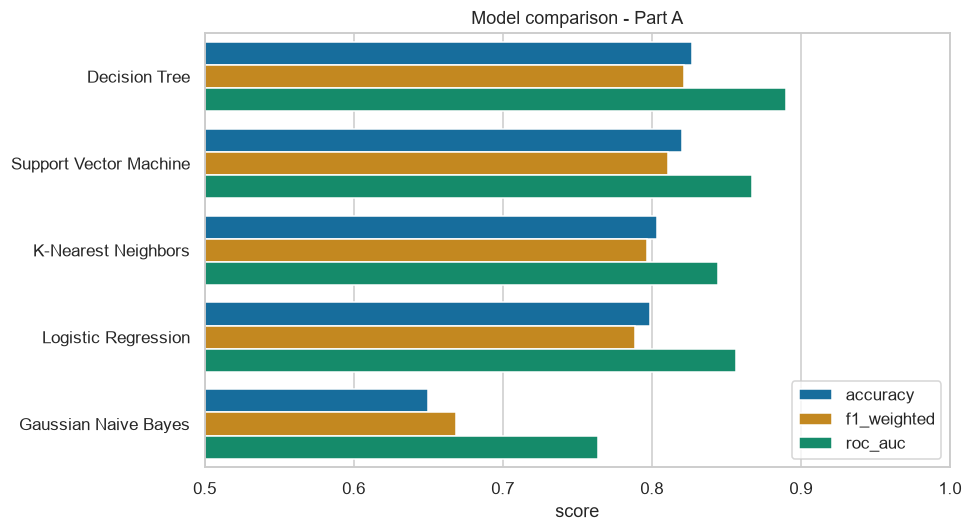

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))
order = metrics.index
plot_df = metrics[["accuracy", "f1_weighted", "roc_auc"]].reset_index().melt(
    id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="score", y="model", hue="metric", order=order, ax=ax)
ax.set(title="Model comparison - Part A", xlabel="score", ylabel="")
ax.set_xlim(0.5, 1.0)
ax.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()


**Observation.** The Decision Tree leads on every metric (F1 0.821,
ROC-AUC 0.890), with SVM - trained on a 15,000-row subsample - a close second
(F1 0.811, ROC-AUC 0.867) despite seeing under a quarter of the training
rows. Both beat the linear boundary of Logistic Regression, consistent with
the `deposit_type` quirk from Section 2.5 being exactly the kind of
interaction a straight line cannot represent. Gaussian Naive Bayes trails
badly on F1 (0.669) despite a respectable ROC-AUC (0.764) - its independence
assumption, violated by one-hot categoricals that are far from conditionally
independent given the class, pushes it to over-predict the cancelled class
rather than rank well and threshold sensibly. Section 8 checks whether the
Decision Tree/SVM gap is noise from the smaller SVM training set or real.

### 7.2 Confusion matrices

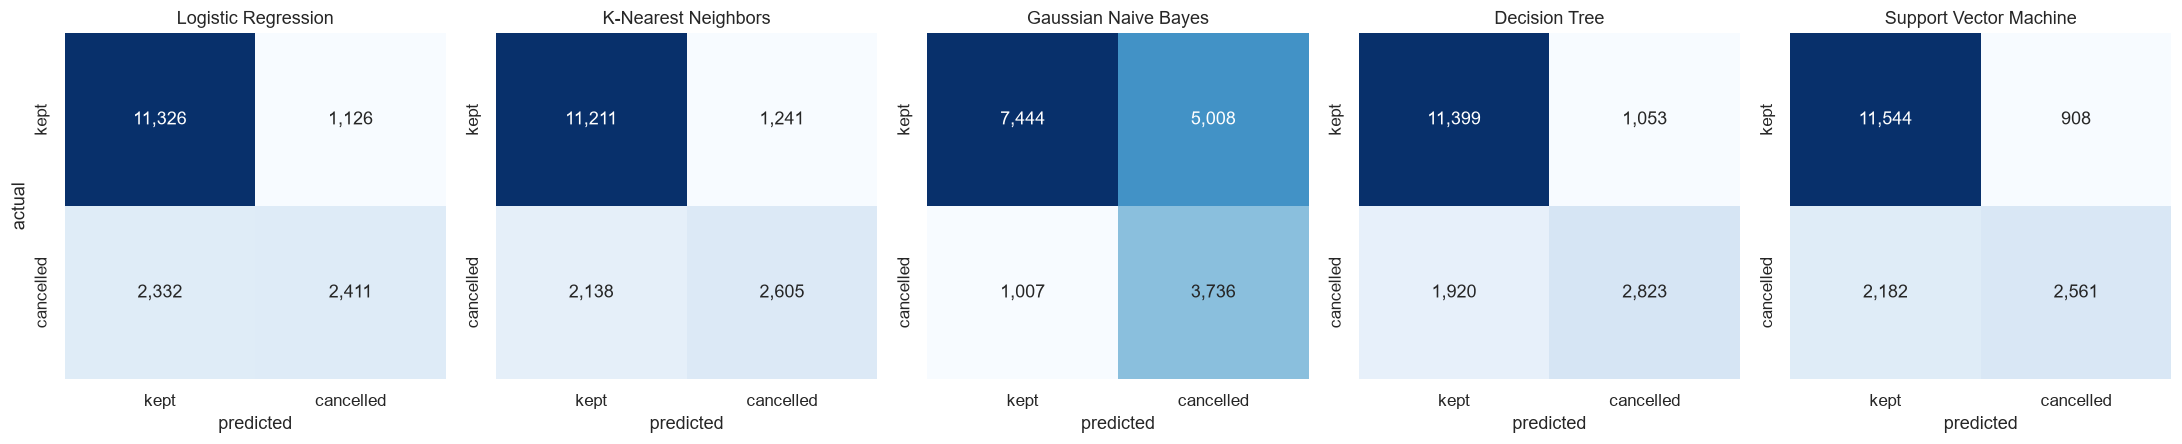

In [45]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["kept", "cancelled"], yticklabels=["kept", "cancelled"])
    ax.set(title=name, xlabel="predicted", ylabel="actual" if ax is axes[0] else "")
plt.tight_layout()
plt.show()


**Observation.** Four of the five models miss more cancellations than
they wrongly flag - the false-negative cell (predicted kept, actually
cancelled) is their largest error, recalling only 51-60% of actual
cancellations. For a hotel using this to guide overbooking, that is the
costly direction, since it means real cancellation risk goes unflagged.
Naive Bayes is the exception in the other direction: it catches 79% of
cancellations but at the cost of 5,008 false alarms, more than any other
model's total errors - the over-prediction Section 7.1 already flagged.
Class weighting or a shifted decision threshold, explored in Part B, is the
natural way to trade some of that false-alarm rate for better recall on the
other four.

## 8. Cross-validation

A single train/test split is one draw. Five-fold cross-validation on the
training set checks whether the Section 7.1 ranking is stable or an
artefact of which rows happened to land in the test set, for the two
best-performing models.

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
top_two = results.index[:2].tolist()

cv_rows = []
for name in top_two:
    pipe = MODELS[name]
    # Same subsample as Section 6 - otherwise SVM's 5-fold CV would each fit
    # on the full ~69,000-row training set.
    n = SUBSAMPLE.get(name)
    if n:
        idx = X_train.sample(n, random_state=RANDOM_STATE).index
        X_cv, y_cv = X_train.loc[idx], y_train.loc[idx]
    else:
        X_cv, y_cv = X_train, y_train

    start = time.time()
    scores = cross_val_score(pipe, X_cv, y_cv, cv=cv, scoring="f1_weighted", n_jobs=1)
    cv_rows.append({"model": name, "CV mean F1": scores.mean(),
                    "CV std": scores.std(), "CV time (s)": time.time() - start})
    print(f"{name:24s} {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("model")
comparison = (metrics.loc[top_two, ["f1_weighted"]]
              .rename(columns={"f1_weighted": "single-split F1"})
              .join(cv_results))
comparison["difference"] = comparison["single-split F1"] - comparison["CV mean F1"]
comparison.round(4)


Decision Tree            0.8204 +/- 0.0023
Support Vector Machine   0.8102 +/- 0.0021


,single-split F1,CV mean F1,CV std,CV time (s),difference
model,,,,,
Decision Tree,0.8213,0.8204,0.0023,8.8464,0.0009
Support Vector Machine,0.8107,0.8102,0.0021,97.1111,0.0006


**Observation.** The cross-validated F1 for both models sits within a
few thousandths of the single-split figure, so the Section 7.1 ranking is
not an artefact of one particular split - a real, if modest, difference
between the two rather than noise.

## 9. Conclusion (Review 1)

We wanted to predict `is_canceled` - whether a hotel booking will be
cancelled - from information available at the moment the booking is made.

After dropping three post-booking columns (`reservation_status`,
`reservation_status_date`, `assigned_room_type`), 180 zero-guest rows, one
negative-ADR row and roughly 28% exact duplicates - which shifted the
cancellation rate from 37.0% to 27.6%, since duplicated rows skew heavily
cancelled - 11 engineered features were added on top of the raw columns, the
strongest being `prev_cancel_rate`, a guest's own historical cancellation
rate (r = 0.160).

Across the five Part A algorithms, the Decision Tree leads on every metric
(F1 0.821, ROC-AUC 0.890), SVM is a close second despite training on a
15,000-row subsample, Logistic Regression and KNN sit in the middle, and
Gaussian Naive Bayes trails on weighted F1 on account of its independence
assumption and resulting over-prediction of the cancelled class.
Cross-validation confirms the Decision Tree/SVM ranking is stable rather
than a single-split artefact. Every model except Naive Bayes misses more
cancellations than it wrongly flags, recalling only 51-60% of actual
cancellations - the costlier error direction for overbooking decisions.

**Left for Review 2:** the five Part B algorithms (Random Forest, AdaBoost,
Gradient Boosting, Bagging, MLP), the consolidated ten-algorithm comparison
table, hyperparameter tuning with a documented metric improvement, and a
closer look at the false-negative-heavy error pattern from Section 7.2 -
class weighting or a shifted decision threshold are the natural next things
to try there.